# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, ridge, xgboost_lgb_feats, tcn, xgb_lstm_stack, xgb_tcn_stack_logreturn, stack_simple_avg, stack_ridge_meta, stack_ridge_meta_logreturn, chronos_returns, chronos_price).

In [19]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "ridge": "metrics_ridge_pool.parquet",
    "ridge_core": "metrics_ridge_core_pool.parquet",
    "xgboost_lgb_feats": "metrics_xgboost_lgb_feats_pool.parquet",
    "tcn": "metrics_tcn_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "xgb_tcn_stack_logreturn": "metrics_xgb_tcn_stack_logreturn_pool.parquet",
    "stack_simple_avg": "metrics_stack_simple_avg_pool.parquet",
    "stack_ridge_meta": "metrics_stack_ridge_meta_pool.parquet",
    "stack_ridge_meta_logreturn": "metrics_stack_ridge_meta_logreturn_pool.parquet",
    "chronos_returns": "metrics_chronos_pool.parquet",
    "chronos_price": "metrics_chronos_pool_price.parquet",
    "xgb_lstm_logreturn":"metrics_xgb_lstm_stack_logreturn_pool.parquet"
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p).copy()
        df["model"] = name
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('MAE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
120,stack_simple_avg,overall,6.311092,8.330929,2.423636
164,chronos_price,overall,6.341592,8.144852,2.430080
109,xgb_tcn_stack_logreturn,overall,6.422700,8.382304,2.445062
43,lightgbm,overall,6.424309,8.417681,2.444576
175,xgb_lstm_logreturn,overall,6.431085,8.399380,2.446703
142,stack_ridge_meta_logreturn,overall,6.432781,8.406946,2.451167
32,xgboost,overall,6.436510,8.444626,2.444875
98,xgb_lstm_stack,overall,6.441181,8.443497,2.446856
153,chronos_returns,overall,6.455411,8.505310,2.454920
65,ridge_core,overall,6.458566,8.451896,2.456347


In [20]:
# Pivot: chronos_price and stack models only — rows = symbol, columns = model, values = MAE / RMSE / MAPE_%
chronos_and_stack = ["chronos_price", "stack_simple_avg", "stack_ridge_meta_logreturn", "xgb_tcn_stack_logreturn", "xgb_lstm_logreturn"]
sub = all_metrics[all_metrics["model"].isin(chronos_and_stack)]
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in sub.columns:
        continue
    pt = sub.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} (chronos_price + stack) ---")
    print(pt.to_string())
    print()


--- MAE (chronos_price + stack) ---
model    chronos_price  stack_ridge_meta_logreturn  stack_simple_avg  xgb_lstm_logreturn  xgb_tcn_stack_logreturn
symbol                                                                                                           
AAPL          6.681341                    6.759644          7.715773            6.830115                 6.832075
AMZN          8.823025                    8.955647          8.269505            8.870453                 8.849339
GOOGL         7.926942                    8.149086          7.876913            8.132274                 8.135877
JNJ           4.587719                    4.043655          3.819888            3.943175                 3.958460
JPM           7.432135                    7.385436          7.389214            7.363375                 7.395979
MSFT         10.396342                   11.022739          9.955287           11.168313                11.066860
NVDA          4.508031                    4.270799 

In [21]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()
# Print only rows where model is chronos_price or any of the stack models



--- MAE ---
model    baseline  chronos_price  chronos_returns   lightgbm       lstm      ridge  ridge_core  stack_ridge_meta  stack_ridge_meta_logreturn  stack_simple_avg        tcn  xgb_lstm_logreturn  xgb_lstm_stack  xgb_tcn_stack_logreturn    xgboost  xgboost_lgb_feats
symbol                                                                                                                                                                                                                                                              
AAPL     6.161693       6.681341         7.082376   6.964995   7.154747   6.745000    6.894274          6.850492                    6.759644          7.715773   7.469595            6.830115        6.925242                 6.832075   7.004899           7.150497
AMZN     8.626306       8.823025         8.949377   8.953874   8.668951   9.105188    9.032965          8.975399                    8.955647          8.269505   9.298197            8.870453        8.93864

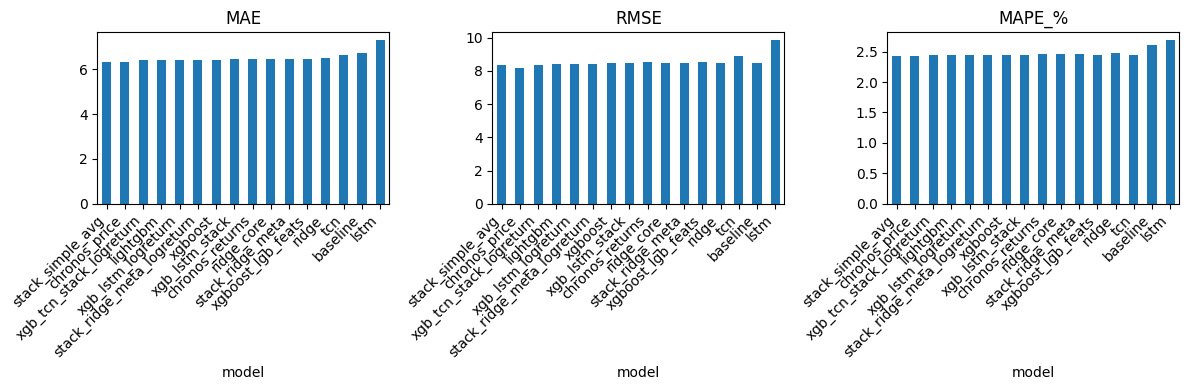

In [22]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()